In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("D:/SANDHYA/DSBDA/StudentPerformance.csv")

In [9]:
df

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_join_Date,Placement_Offer
0,75.0,89.0,63.0,86.0,2020,3
1,69.0,92.0,64.0,88.0,2022,3
2,78.0,78.0,69.0,94.0,2019,3
3,78.0,78.0,65.0,100.0,2021,3
4,74.0,NaN,60.0,81.0,2020,2
...,...,...,...,...,...,...
94,64.0,78.0,69.0,85.0,2019,3
95,68.0,79.0,77.0,87.0,2020,3
96,94.0,91.0,64.0,99.0,2019,3
97,69.0,92.0,67.0,93.0,2019,3


In [11]:
df.head()

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_join_Date,Placement_Offer
0,75.0,89.0,63.0,86.0,2020,3
1,69.0,92.0,64.0,88.0,2022,3
2,78.0,78.0,69.0,94.0,2019,3
3,78.0,78.0,65.0,100.0,2021,3
4,74.0,NaN,60.0,81.0,2020,2


In [13]:
df.columns


Index(['Math_Score', 'Reading_Score', 'Writing_Score', 'Placement_Score',
       'Club_join_Date', 'Placement_Offer'],
      dtype='object')

In [15]:
df.dtypes

Math_Score         float64
Reading_Score      float64
Writing_Score      float64
Placement_Score    float64
Club_join_Date       int64
Placement_Offer      int64
dtype: object

In [17]:
df.isnull().sum()

Math_Score         3
Reading_Score      6
Writing_Score      1
Placement_Score    4
Club_join_Date     0
Placement_Offer    0
dtype: int64

In [19]:
df.isnull().sum().sum()


14

In [23]:
df.drop([20,21,22,23],inplace=True)
df

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_join_Date,Placement_Offer
0,75.0,89.0,63.0,86.0,2020,3
1,69.0,92.0,64.0,88.0,2022,3
2,78.0,78.0,69.0,94.0,2019,3
3,78.0,78.0,65.0,100.0,2021,3
4,74.0,NaN,60.0,81.0,2020,2
...,...,...,...,...,...,...
94,64.0,78.0,69.0,85.0,2019,3
95,68.0,79.0,77.0,87.0,2020,3
96,94.0,91.0,64.0,99.0,2019,3
97,69.0,92.0,67.0,93.0,2019,3


In [25]:
df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].mean())
df['Reading_Score'] = df['Reading_Score'].fillna(df['Reading_Score'].median())
df['Writing_Score'] = df['Writing_Score'].fillna(df['Writing_Score'].mode())
df['Placement_Score'] = df['Placement_Score'].fillna(df['Placement_Score'].mean())

In [27]:
df

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_join_Date,Placement_Offer
0,75.0,89.0,63.0,86.0,2020,3
1,69.0,92.0,64.0,88.0,2022,3
2,78.0,78.0,69.0,94.0,2019,3
3,78.0,78.0,65.0,100.0,2021,3
4,74.0,86.0,60.0,81.0,2020,2
...,...,...,...,...,...,...
94,64.0,78.0,69.0,85.0,2019,3
95,68.0,79.0,77.0,87.0,2020,3
96,94.0,91.0,64.0,99.0,2019,3
97,69.0,92.0,67.0,93.0,2019,3


In [37]:
df['Club_join_Date'] = df['Club_join_Date'].fillna(df['Club_join_Date'].mode())
df

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_join_Date,Placement_Offer
0,75.0,89.0,63.0,86.0,2020,3
1,69.0,92.0,64.0,88.0,2022,3
2,78.0,78.0,69.0,94.0,2019,3
3,78.0,78.0,65.0,100.0,2021,3
4,74.0,86.0,60.0,81.0,2020,2
...,...,...,...,...,...,...
94,64.0,78.0,69.0,85.0,2019,3
95,68.0,79.0,77.0,87.0,2020,3
96,94.0,91.0,64.0,99.0,2019,3
97,69.0,92.0,67.0,93.0,2019,3


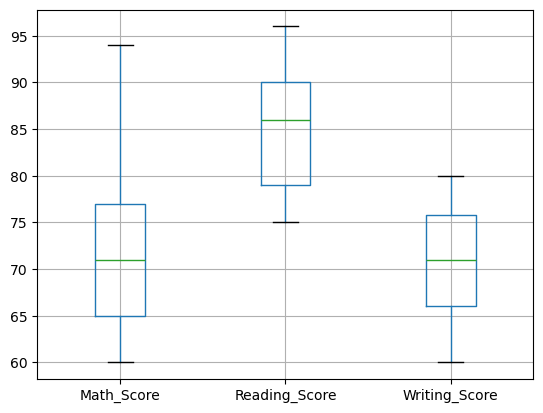

In [39]:
col = ['Math_Score', 'Reading_Score', 'Writing_Score']
df.boxplot(col)
plt.show()

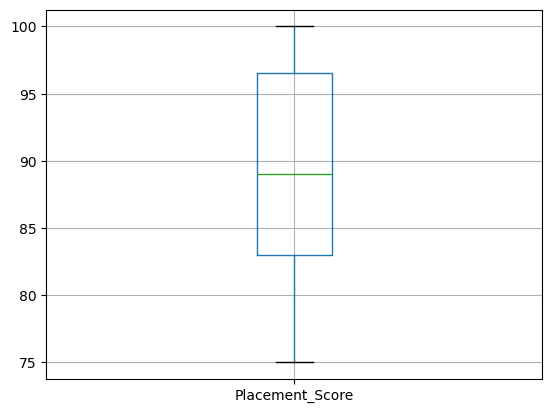

In [41]:
col = ['Placement_Score']
df.boxplot(col)
plt.show()


In [51]:
from scipy import stats
import numpy as np
z = np.abs(stats.zscore(df['Math_Score']))
print(z)


0     0.624369
1     0.289826
2     1.081466
3     1.081466
4     0.472003
        ...   
94    1.051656
95    0.442192
96    3.519320
97    0.289826
98    0.014905
Name: Math_Score, Length: 95, dtype: float64


In [53]:
np.where

<function where at 0x000001F8D47FF830>

In [55]:
threshold = 3
np.where(z > threshold)

(array([92], dtype=int64),)

In [57]:
sorted_rscore = sorted(df['Reading_Score'])
q1 = np.percentile(sorted_rscore, 25)
q3 = np.percentile(sorted_rscore, 75)
IQR = q3-q1
lower = q1-(1.5 * IQR)
upper = q3 + (1.5 * IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: 62.5
Upper Bound: 106.5


In [65]:
outliers = []
for i in sorted_rscore:
    if i < lower or i > upper:
        outliers.append(i)
outliers

[]

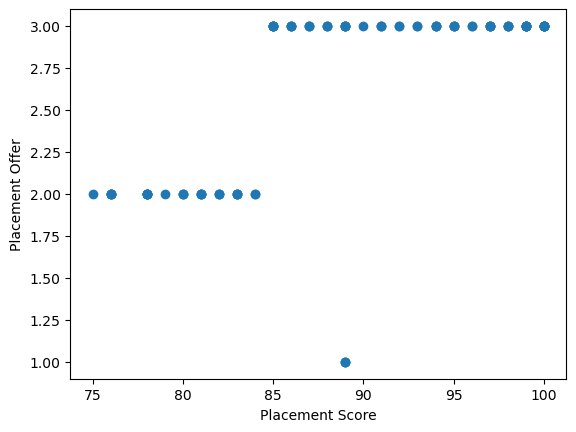

In [69]:
plt.scatter(df['Placement_Score'], df['Placement_Offer'])
plt.xlabel("Placement Score")
plt.ylabel("Placement Offer")
plt.show()

In [71]:
print(np.where((df['Placement_Score'] > 85) & (df['Placement_Offer'] < 3)))

(array([ 8, 71, 79], dtype=int64),)


In [73]:
Q1 = df['Reading_Score'].quantile(0.25)
Q3 = df['Reading_Score'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5 * IQR
upper = Q3 + 1.5 * IQR

In [78]:
median = np.median(sorted_rscore)
df['Reading_Score'] = np.where(
    df['Reading_Score'] > upper,
    median,
    df['Reading_Score']
)
df['Reading_Score'] = np.where(
    df['Reading_Score'] < lower,
    median,
    df['Reading_Score']
)
df

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_join_Date,Placement_Offer
0,75.0,89.0,63.0,86.0,2020,3
1,69.0,92.0,64.0,88.0,2022,3
2,78.0,78.0,69.0,94.0,2019,3
3,78.0,78.0,65.0,100.0,2021,3
4,74.0,86.0,60.0,81.0,2020,2
...,...,...,...,...,...,...
94,64.0,78.0,69.0,85.0,2019,3
95,68.0,79.0,77.0,87.0,2020,3
96,94.0,91.0,64.0,99.0,2019,3
97,69.0,92.0,67.0,93.0,2019,3


In [80]:
df.loc[df['Placement_Score'] < 75, 'Placement_Offer'] = 1
df.loc[
    (df['Placement_Score'] >= 75) & (df['Placement_Score'] <= 85),
    'Placement_Offer_Count'
] = 2
df.loc[df['Placement_Score'] > 85, 'Placement_Offer'] = 3

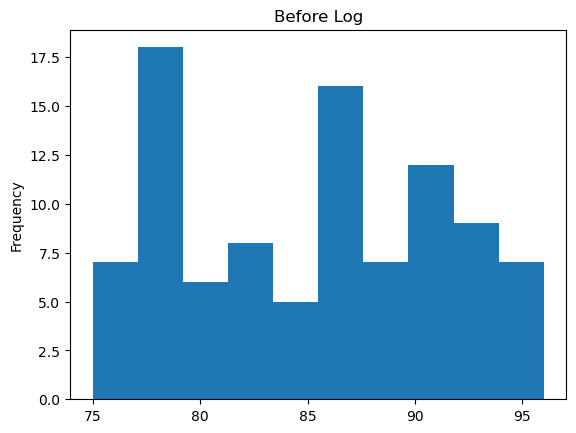

In [82]:
df['Reading_Score'].plot(kind='hist')
plt.title("Before Log")
plt.show()

In [ ]:
df['log_reading'] = np.log10(df['Reading_Score'])
df['log_reading'].plot(kind='hist')
plt.title("After Log")
plt.show()
